# Task 3: Mock z~7.5 Lya Lines

$$F_{\rm mock}(\lambda) = F_{\rm intrinsic}(\lambda) \times T_{\rm IGM}(\lambda)$$

- **Intrinsic**: DEIMOS LAE spectrum at z=3-5 (IGM transparent), resampled and continuum-normalised
- **Transmission**: simulation curve at z=7.4985 (~50% neutral IGM)
- **Mock**: what a z~7.5 LAE would look like through a spectrograph

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
d    = np.load(ROOT / 'results/task3_mock_lya_lines/mock_z7.4985.npz')

wav          = d['wav']
mock         = d['mock_spectra']
transmission = d['transmission']
bubble_size  = d['bubble_size']
n_templates  = int(d['n_templates'])

print(f'Mock spectra : {mock.shape}')
print(f'Templates    : {n_templates}')
print(f'Wavelength   : {wav.min():.1f} - {wav.max():.1f} A')
print(f'Bubble sizes : min={bubble_size.min():.1f}  median={np.median(bubble_size):.1f}  max={bubble_size.max():.1f} Mpc/h')
print(f'Mock flux p50={np.percentile(mock,50):.3f}  p99={np.percentile(mock,99):.2f}  max={mock.max():.1f}')

Mock spectra : (10000, 2000)
Templates    : 46
Wavelength   : 1165.8 - 1350.7 A
Bubble sizes : min=1.0  median=3.8  max=25.9 Mpc/h
Mock flux p50=0.186  p99=8.65  max=90.8


## 1. A few mock spectra vs transmission and intrinsic template

/tmp/ipykernel_239855/2594619024.py:11: RuntimeWarning: invalid value encountered in divide
  intr = np.where(safe, M / T, np.nan)


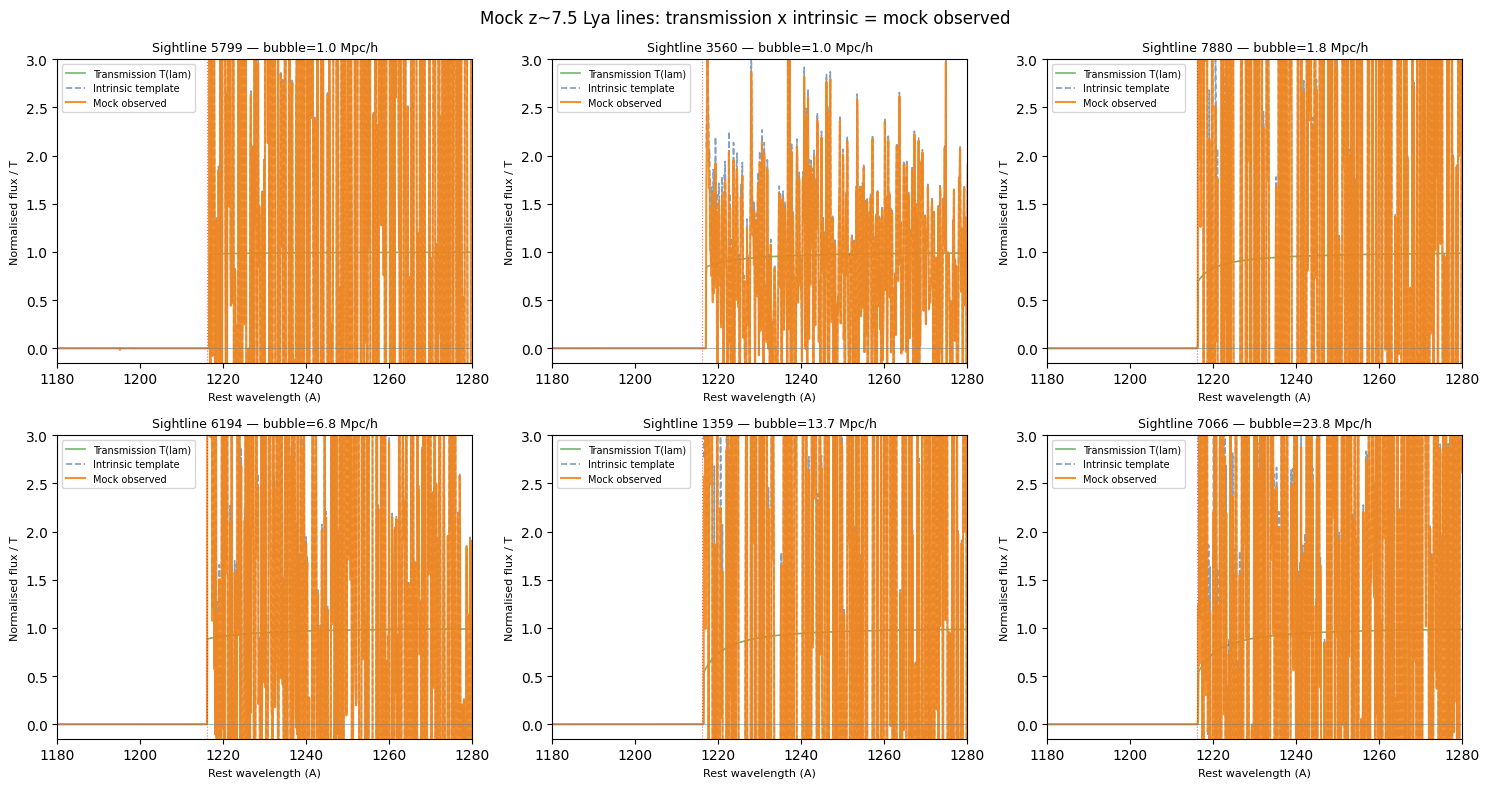

In [2]:
idx_sorted = np.argsort(bubble_size)
picks = idx_sorted[np.linspace(50, len(idx_sorted)-50, 6, dtype=int)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, i in zip(axes, picks):
    T = transmission[i]
    M = mock[i]
    safe = T > 0.01
    intr = np.where(safe, M / T, np.nan)
    ylim = min(3.0, float(np.nanpercentile(intr, 98)) * 1.3)

    ax.plot(wav, T,    color='#54A24B', lw=1.2, label='Transmission T(lam)', alpha=0.8)
    ax.plot(wav, intr, color='#4C78A8', lw=1.2, label='Intrinsic template',  alpha=0.7, ls='--')
    ax.plot(wav, M,    color='#F58518', lw=1.5, label='Mock observed',        alpha=0.9)
    ax.axvline(1216, color='red', lw=0.8, ls=':', alpha=0.6)
    ax.axhline(0,    color='gray', lw=0.4)
    ax.set_xlim(1180, 1280)
    ax.set_ylim(-0.15, max(1.5, ylim))
    ax.set_title(f'Sightline {i} — bubble={bubble_size[i]:.1f} Mpc/h', fontsize=9)
    ax.set_xlabel('Rest wavelength (A)', fontsize=8)
    ax.set_ylabel('Normalised flux / T', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle('Mock z~7.5 Lya lines: transmission x intrinsic = mock observed', fontsize=12)
fig.tight_layout()
plt.show()

## 2. Check peak flux distribution (flag outlier templates)

  p 50.0 = 12.56
  p 90.0 = 40.12
  p 95.0 = 48.69
  p 99.0 = 90.52
  p 99.9 = 90.73
  p100.0 = 90.81


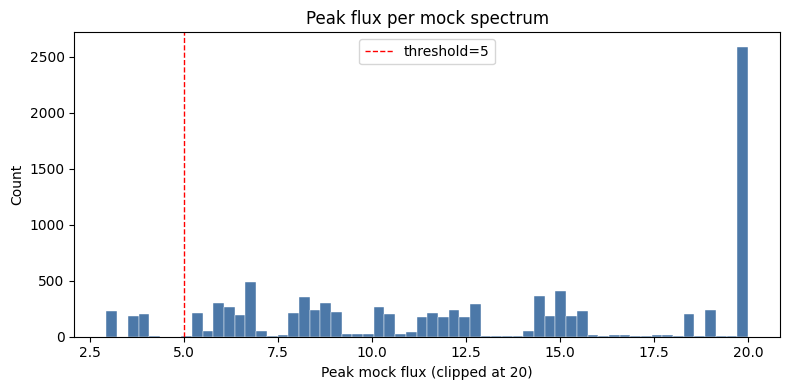

Sightlines with peak > 5: 9376 (93.8%)


In [3]:
peak_flux = mock.max(axis=1)
for p in [50, 90, 95, 99, 99.9, 100]:
    print(f'  p{p:5.1f} = {np.percentile(peak_flux, p):.2f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(peak_flux, 0, 20), bins=60, color='#4C78A8', edgecolor='white', lw=0.3)
ax.axvline(5, color='red', ls='--', lw=1, label='threshold=5')
ax.set_xlabel('Peak mock flux (clipped at 20)')
ax.set_ylabel('Count')
ax.set_title('Peak flux per mock spectrum')
ax.legend()
fig.tight_layout()
plt.show()
print(f'Sightlines with peak > 5: {(peak_flux > 5).sum()} ({(peak_flux>5).mean()*100:.1f}%)')

## 3. Small vs large bubble — stacked mock spectra

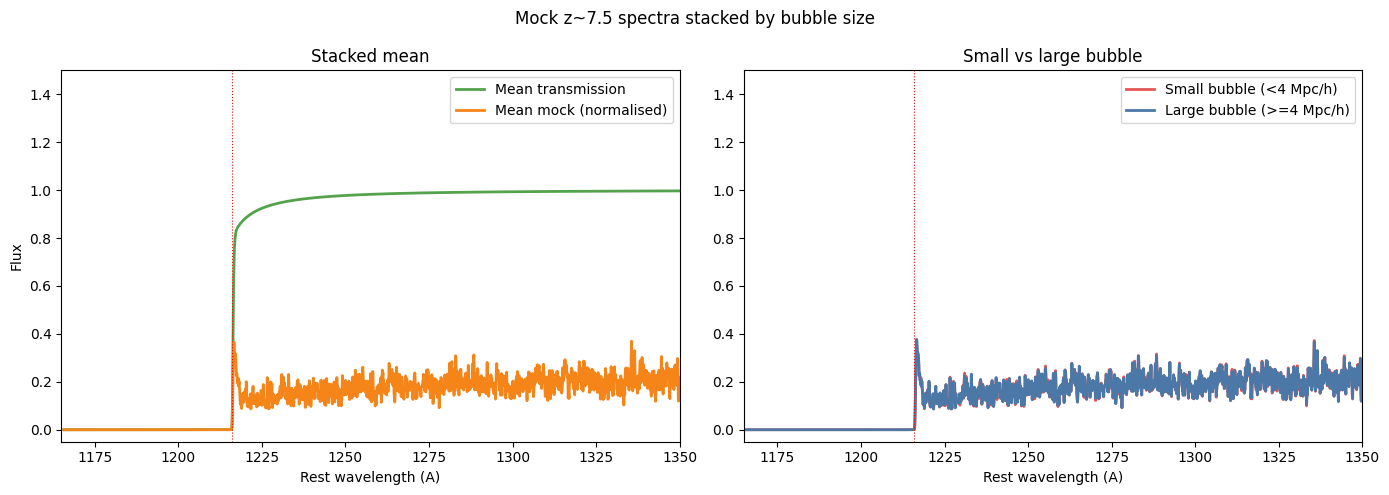

In [4]:
# Clip extreme spectra before stacking
clip_val = np.percentile(mock, 99)
mock_clip = np.clip(mock, 0, clip_val)
norm = mock_clip.max(axis=1, keepdims=True)
norm = np.where(norm > 0, norm, 1.0)
mock_norm = mock_clip / norm

med_b = np.median(bubble_size[bubble_size > 0])
small = bubble_size < med_b
large = bubble_size >= med_b

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wav, np.mean(transmission, axis=0), color='#54A24B', lw=2, label='Mean transmission')
axes[0].plot(wav, np.mean(mock_norm,    axis=0), color='#F58518', lw=2, label='Mean mock (normalised)')
axes[0].axvline(1216, color='red', lw=0.8, ls=':')
axes[0].set_xlim(1165, 1350); axes[0].set_ylim(-0.05, 1.5)
axes[0].set_xlabel('Rest wavelength (A)'); axes[0].set_ylabel('Flux')
axes[0].set_title('Stacked mean'); axes[0].legend()

axes[1].plot(wav, np.mean(mock_norm[small], axis=0), color='#E45756', lw=2, label=f'Small bubble (<{med_b:.0f} Mpc/h)')
axes[1].plot(wav, np.mean(mock_norm[large], axis=0), color='#4C78A8', lw=2, label=f'Large bubble (>={med_b:.0f} Mpc/h)')
axes[1].axvline(1216, color='red', lw=0.8, ls=':')
axes[1].set_xlim(1165, 1350); axes[1].set_ylim(-0.05, 1.5)
axes[1].set_xlabel('Rest wavelength (A)')
axes[1].set_title('Small vs large bubble')
axes[1].legend()

fig.suptitle('Mock z~7.5 spectra stacked by bubble size', fontsize=12)
fig.tight_layout()
plt.show()